In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("16-diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
columns_for_check = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in columns_for_check:
    zero_count = (df[col] == 0).sum()
    zero_percentge = 100 * zero_count / len(df)
    print(f"{col}: {zero_count} %{zero_percentge:.2f}")

Glucose: 5 %0.65
BloodPressure: 35 %4.56
SkinThickness: 227 %29.56
Insulin: 374 %48.70
BMI: 11 %1.43


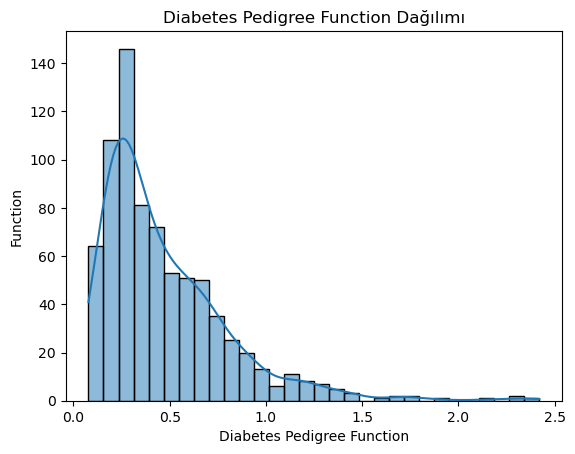

In [8]:
sns.histplot(df["DiabetesPedigreeFunction"],bins=30,kde=True)
plt.title("Diabetes Pedigree Function Dağılımı")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Function")
plt.show()

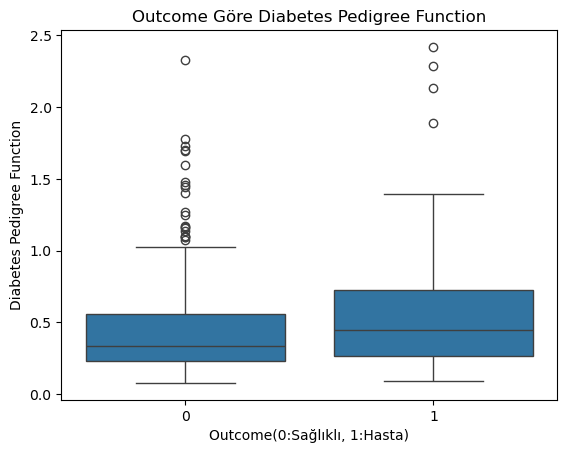

In [9]:
sns.boxplot(x="Outcome", y="DiabetesPedigreeFunction",data=df)
plt.title("Outcome Göre Diabetes Pedigree Function")
plt.xlabel("Outcome(0:Sağlıklı, 1:Hasta)")
plt.ylabel("Diabetes Pedigree Function")
plt.show()

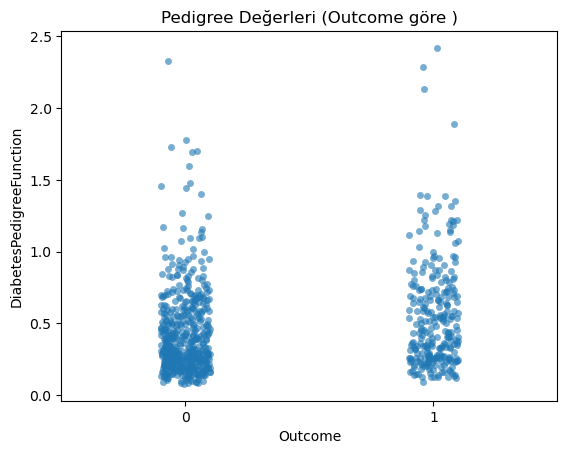

In [10]:
sns.stripplot(x="Outcome",y="DiabetesPedigreeFunction",data=df,jitter=True,alpha=0.6)
plt.title("Pedigree Değerleri (Outcome göre )")
plt.show()

In [11]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [13]:
columns_to_fill = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

In [14]:
medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] !=0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0,median_value)

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0,medians[col])

In [15]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [16]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

In [19]:
ada = AdaBoostClassifier()
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)

In [20]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
adaboost_param =  {
        "n_estimators" : [50,70,100,120,150,200],
        "learning_rate" : [0.001,0.01,0.1,1,10]
}

In [23]:
grid = GridSearchCV(estimator = AdaBoostClassifier(),param_grid = adaboost_param, cv=5,verbose=1,n_jobs=-1)

In [24]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,AdaBoostClassifier()
,param_grid,"{'learning_rate': [0.001, 0.01, ...], 'n_estimators': [50, 70, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [25]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [26]:
grid.best_score_

np.float64(0.757270425163268)

In [27]:
ada = AdaBoostClassifier(learning_rate=1,n_estimators=150)
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)

In [28]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

0.7597402597402597
[[87 21]
 [16 30]]


In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)

In [31]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.59      0.59      0.59        46

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

0.7532467532467533
[[89 19]
 [19 27]]


In [32]:
model = LogisticRegression()

In [33]:
penalty = ["l1","l2","elasticnet"]
c_values = [100,10,1,0.1,0.01]
solver = ["lbfgs","liblinear","newton-cg","newton-cholesky","sag","saga"]

In [34]:
params = dict(penalty=penalty, C=c_values, solver=solver)
import warnings
warnings.filterwarnings("ignore")

In [35]:
grid = GridSearchCV(estimator=model, param_grid=params,cv=5,scoring="accuracy",verbose=1,n_jobs=-1)

In [36]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [37]:
grid.best_params_

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}

In [38]:
grid.best_score_

np.float64(0.7719712115153938)

In [39]:
model2 = LogisticRegression(C=100,penalty="l1",solver="liblinear")

In [40]:
model2.fit(X_train,y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = model2.predict(X_test)

In [42]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       108
           1       0.57      0.59      0.58        46

    accuracy                           0.75       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.75      0.75      0.75       154

0.7467532467532467
[[88 20]
 [19 27]]


In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

In [45]:
param_grid = {
    "n_estimators" : [100,200,300],
    "max_depth" : [None,2,5,10,20],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,3,4,5],
    "max_features" : ["sqrt","log2"]
}

In [46]:
grid = GridSearchCV(estimator=rf, param_grid=param_grid,cv=5,scoring="accuracy",verbose=1,n_jobs=-1)

In [47]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 2, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [48]:
grid.best_params_

{'max_depth': 20,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [49]:
grid.best_score_

np.float64(0.7866053578568571)

In [50]:
model3 = RandomForestClassifier(max_depth=20,max_features="sqrt",min_samples_leaf=2,min_samples_split=2,n_estimators=100)

In [51]:
model3.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred = model3.predict(X_test)

In [53]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       108
           1       0.53      0.54      0.54        46

    accuracy                           0.72       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.72      0.72      0.72       154

0.7207792207792207
[[86 22]
 [21 25]]


In [54]:
from sklearn.svm import SVC

In [55]:
svc = SVC(kernel="linear")

In [56]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
y_pred = svc.predict(X_test)

In [58]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.58      0.57      0.57        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.75      0.75      0.75       154

0.7467532467532467
[[89 19]
 [20 26]]


In [59]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train,y_train)
y_pred = rbf.predict(X_test)

In [60]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       108
           1       0.54      0.54      0.54        46

    accuracy                           0.73       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.73      0.73      0.73       154

0.7272727272727273
[[87 21]
 [21 25]]


In [61]:
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
param_grid = {
    "C" : [0.1,1,10,100,1000],
    "kernel" : ["rbf","linear"],
    "gamma" : ["scale","auto"]
}   

In [63]:
grid = GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5)

In [64]:
grid.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [65]:
grid.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

In [66]:
grid.best_score_

np.float64(0.7703318672530987)

In [67]:
sVc = SVC(C=1,gamma="scale",kernel="linear")

In [68]:
sVc.fit(X_train,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [69]:
y_pred = sVc.predict(X_test)

In [70]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.58      0.57      0.57        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.75      0.75      0.75       154

0.7467532467532467
[[89 19]
 [20 26]]


In [71]:
from sklearn.neighbors import KNeighborsClassifier

In [72]:
classifer = KNeighborsClassifier()

In [73]:
classifer.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
y_pred = classifer.predict(X_test)

In [75]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.75      0.78       108
           1       0.49      0.57      0.53        46

    accuracy                           0.69       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.71      0.69      0.70       154

0.6948051948051948
[[81 27]
 [20 26]]


In [76]:
from sklearn.metrics import precision_score,recall_score,f1_score

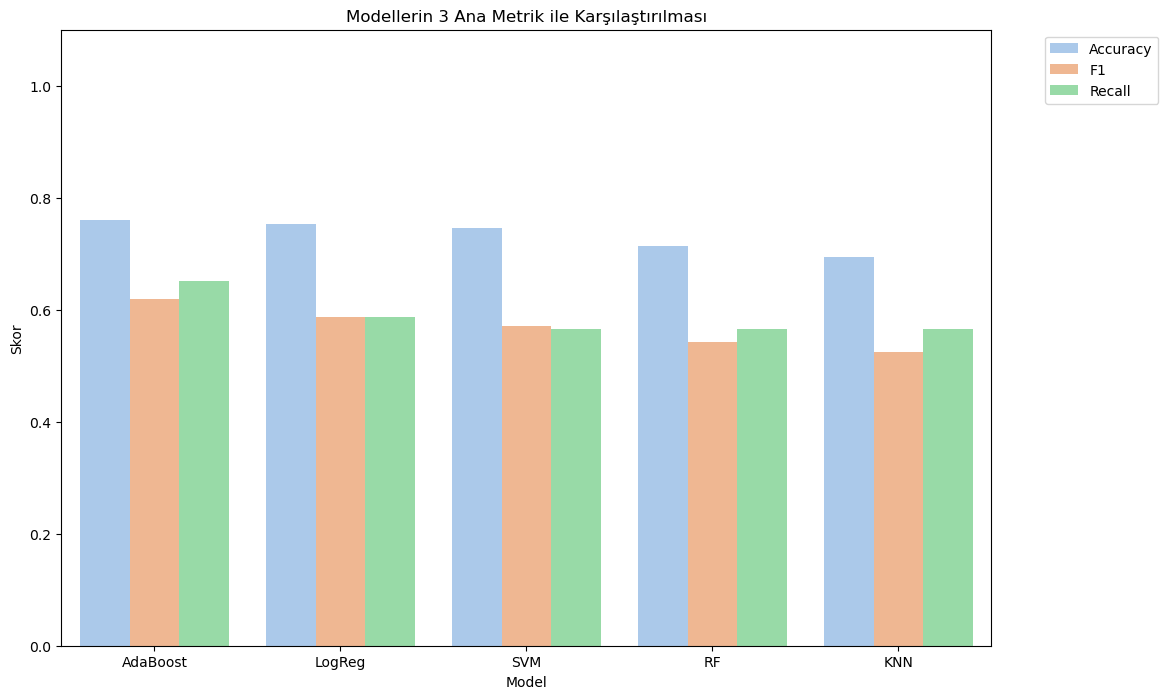

      Model  Accuracy        F1    Recall
0  AdaBoost  0.759740  0.618557  0.652174
1    LogReg  0.753247  0.586957  0.586957
3       SVM  0.746753  0.571429  0.565217
2        RF  0.714286  0.541667  0.565217
4       KNN  0.694805  0.525253  0.565217


In [77]:
def modelKiyasla (modeller,X_test,y_test):
    ozet_veriler = []

    for isim, model in modeller.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test,y_pred)
        rapor = classification_report(y_test,y_pred)
        precision = precision_score(y_test,y_pred)
        recall = recall_score(y_test,y_pred)
        f1 = f1_score(y_test,y_pred)

        ozet_veriler.append({
            "Model":isim,
            "Accuracy":acc,
            "F1":f1,
            "Recall":recall
        })
    df_kiyas = pd.DataFrame(ozet_veriler).sort_values(by="Accuracy",ascending=False)
    df_plot = df_kiyas.melt(id_vars="Model",var_name="Metrik",value_name="Skor")
    

    plt.figure(figsize=(12,8))
    sns.barplot(x="Model",y="Skor",hue="Metrik",data=df_plot,palette="pastel")
    plt.title("Modellerin 3 Ana Metrik ile Karşılaştırılması")
    plt.ylim(0,1.1)
    plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
    plt.show()

    return df_kiyas

modellerim = {"AdaBoost":ada,"LogReg":logistic,"RF":rf,"SVM":svc,"KNN":classifer}
sonuc_tablosu = modelKiyasla(modellerim,X_test,y_test)
print(sonuc_tablosu)